# Study 0: simulation EDA and blind-analysis benchmark

This notebook is intended to analyze the observed response data without using the hidden generating traits directly. The primary goal is to characterize the simulation and to evaluate how well psychometric structure can be recovered.

## Workflow

1. Load the observed response files.
2. Inspect response distributions and missingness.
3. Compute summary measures of accuracy, calibration, updating, verification, and sharing behavior.
4. Estimate a provisional latent structure.
5. Compare estimates to the hidden generating parameters after the blind-analysis stage.

In [1]:
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

root = pathlib.Path('..')
data_dir = root / 'data' / 'simulated'

participants = pd.read_csv(data_dir / 'participants.csv')
items = pd.read_csv(data_dir / 'items.csv')
veracity = pd.read_csv(data_dir / 'veracity_responses.csv')
updating = pd.read_csv(data_dir / 'updating_responses.csv')
verification = pd.read_csv(data_dir / 'verification_responses.csv')
scores = pd.read_csv(data_dir / 'scale_scores.csv')

observed_metrics = [
    'accuracy_total',
    'true_item_accuracy',
    'false_item_accuracy',
    'dprime',
    'criterion',
    'mean_confidence',
    'confidence_accuracy_gap',
    'brier_score',
    'share_rate',
    'sharing_restraint_score',
    'updating_success_rate',
    'mean_appropriate_movement',
    'verification_accuracy',
]

participant_summary = scores.copy()
participant_summary = participant_summary.merge(
    veracity.groupby('participant_id').agg(
        careless_trial_rate=('careless_trial', 'mean'),
        share_rate_obs=('share', 'mean'),
        mean_confidence_obs=('confidence', 'mean'),
        mean_response_time=('response_time_seconds', 'mean'),
    ),
    on='participant_id',
    how='left',
)

participant_summary.head()

,participant_id,accuracy_total,true_item_accuracy,false_item_accuracy,dprime,criterion,mean_confidence,confidence_accuracy_gap,brier_score,share_rate,sharing_restraint_score,updating_success_rate,mean_appropriate_movement,verification_accuracy,careless_trial_rate,share_rate_obs,mean_confidence_obs,mean_response_time
0,P0001,0.575,1.00,0.15,1.013331,-1.474087,90.85375,0.333537,0.320941,0.100,0.900,0.7,0.19846,0.5,0.075,0.100,90.85375,7.25750
1,P0002,0.525,0.80,0.25,0.154154,-0.714561,81.86100,0.293610,0.325128,0.300,0.700,0.6,0.10823,0.8,0.075,0.300,81.86100,9.94500
2,P0003,0.900,0.85,0.95,2.432655,0.248906,84.09200,-0.059080,0.087016,0.300,0.700,1.0,0.09128,0.4,0.025,0.300,84.09200,10.34625
3,P0004,0.525,0.75,0.30,0.140284,-0.567342,83.51550,0.310155,0.324431,0.275,0.725,0.7,0.12003,0.7,0.000,0.275,83.51550,11.22350
4,P0005,0.700,0.80,0.60,1.032679,-0.275299,80.46925,0.104692,0.205703,0.250,0.750,0.9,0.08310,0.4,0.175,0.250,80.46925,9.52250


## 1. Basic dataset check

Inspect the available files and row counts before analysis.

In [2]:
datasets = {
    'participants': participants,
    'items': items,
    'veracity': veracity,
    'updating': updating,
    'verification': verification,
    'scores': scores,
}

print('Dataset shapes:')
for name, df in datasets.items():
    print(f'{name}: {df.shape[0]} rows x {df.shape[1]} columns')

print('\nLatent columns available in participants.csv:')
print(participants.columns.tolist())


Dataset shapes:
participants: 1000 rows x 12 columns
items: 60 rows x 15 columns
veracity: 40000 rows x 14 columns
updating: 10000 rows x 12 columns
verification: 10000 rows x 6 columns
scores: 1000 rows x 14 columns

Latent columns available in participants.csv:
['participant_id', 'discernment', 'calibration', 'evidence_evaluation', 'updating', 'verification', 'sharing_restraint', 'general_knowledge', 'credulity_bias', 'congruence_susceptibility', 'emotional_reactivity', 'carelessness']


## 2. Response distributions

Explore central behavior: accuracy, confidence, share propensity, and careless response rates.

In [3]:
# Observed accuracy and calibration summaries
summary = {
    'avg_accuracy': veracity['correct'].mean(),
    'avg_confidence': veracity['confidence'].mean(),
    'share_rate': veracity['share'].mean(),
    'careless_trial_rate': veracity['careless_trial'].mean(),
    'updating_success_rate': updating['post_correct'].mean(),
    'verification_accuracy': verification['correct'].mean(),
}

for k, v in summary.items():
    print(f'{k}: {v:.3f}')


avg_accuracy: 0.605
avg_confidence: 83.314
share_rate: 0.419
careless_trial_rate: 0.057
updating_success_rate: 0.761
verification_accuracy: 0.445


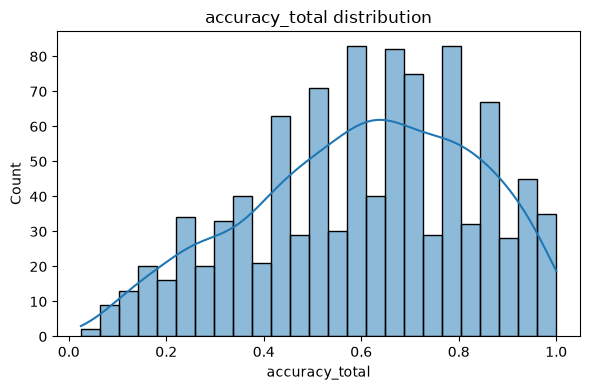

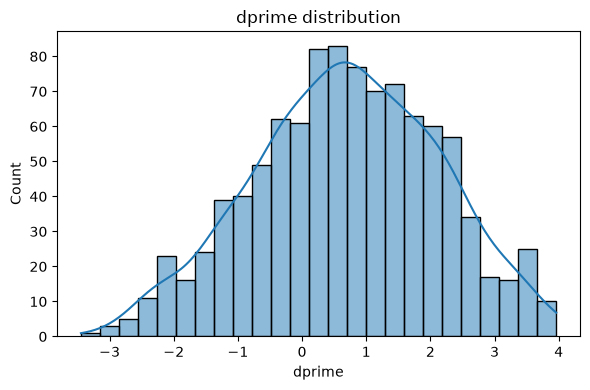

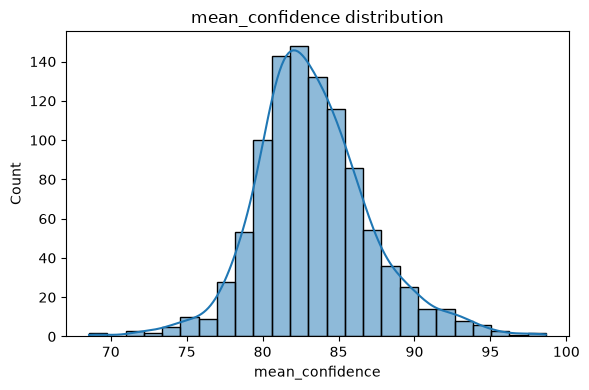

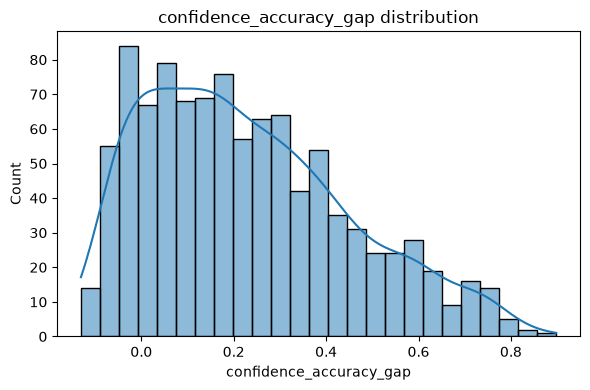

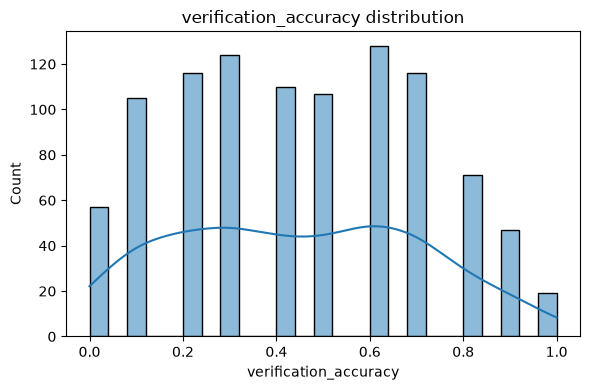

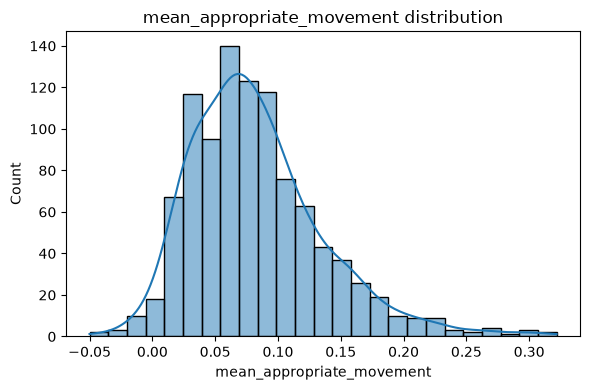

In [4]:
# Participant-level distributions
for col in ['accuracy_total', 'dprime', 'mean_confidence', 'confidence_accuracy_gap', 'verification_accuracy', 'mean_appropriate_movement']:
    plt.figure(figsize=(6, 4))
    sns.histplot(participant_summary[col], bins=25, kde=True)
    plt.title(f'{col} distribution')
    plt.tight_layout()
    plt.show()


## 3. Participant-level summary analysis

Create a participant dataframe for measurement-level exploration.

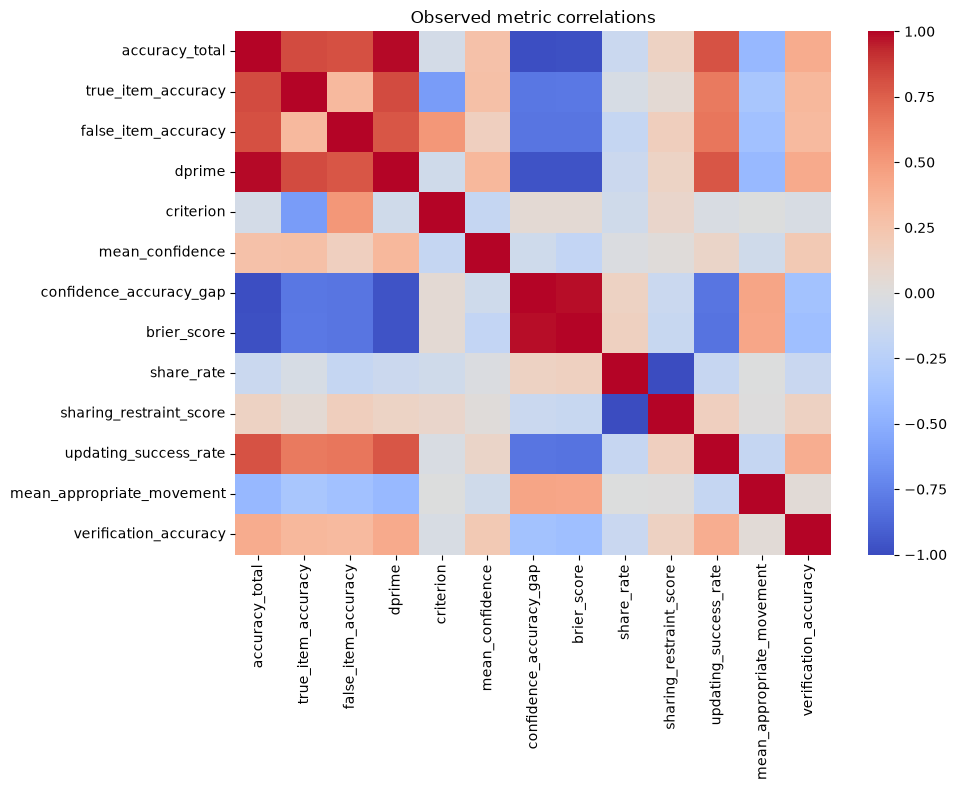

,accuracy_total,true_item_accuracy,false_item_accuracy,dprime,criterion,mean_confidence,confidence_accuracy_gap,brier_score,share_rate,sharing_restraint_score,updating_success_rate,mean_appropriate_movement,verification_accuracy
accuracy_total,1.000,0.821,0.808,0.988,-0.074,0.270,-0.986,-0.982,-0.133,0.133,0.801,-0.441,0.398
true_item_accuracy,0.821,1.000,0.327,0.822,-0.616,0.279,-0.800,-0.794,-0.050,0.050,0.648,-0.340,0.333
false_item_accuracy,0.808,0.327,1.000,0.788,0.513,0.160,-0.807,-0.807,-0.170,0.170,0.657,-0.380,0.316
dprime,0.988,0.822,0.788,1.000,-0.100,0.334,-0.963,-0.968,-0.129,0.129,0.781,-0.435,0.409
criterion,-0.074,-0.616,0.513,-0.100,1.000,-0.168,0.047,0.047,-0.095,0.095,-0.038,-0.001,-0.039
mean_confidence,0.270,0.279,0.160,0.334,-0.168,1.000,-0.106,-0.183,-0.019,0.019,0.111,-0.101,0.216
confidence_accuracy_gap,-0.986,-0.800,-0.807,-0.963,0.047,-0.106,1.000,0.983,0.135,-0.135,-0.808,0.438,-0.374
brier_score,-0.982,-0.794,-0.807,-0.968,0.047,-0.183,0.983,1.000,0.150,-0.150,-0.820,0.432,-0.398
share_rate,-0.133,-0.050,-0.170,-0.129,-0.095,-0.019,0.135,0.150,1.000,-1.000,-0.161,-0.001,-0.144
sharing_restraint_score,0.133,0.050,0.170,0.129,0.095,0.019,-0.135,-0.150,-1.000,1.000,0.161,0.001,0.144


In [5]:
# Correlation matrix among observed summary metrics
corr = participant_summary[observed_metrics].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm', vmin=-1, vmax=1, annot=False)
plt.title('Observed metric correlations')
plt.tight_layout()
plt.show()

corr.round(3)

## 5. Blind-analysis validation against hidden generating parameters

This is the key Study 0 step: compute observed-only measures and then compare them to the hidden latent variables in the simulated participant file. The idea is to estimate the recovery quality of the psychometric design, not to use the true parameters during model fitting.

In [7]:
# Hidden-vs-observed recovery checks
# We intentionally use the hidden latent variables only after constructing observed metrics.
recovery = participants[['participant_id', 'discernment', 'calibration', 'evidence_evaluation', 'updating', 'verification', 'sharing_restraint', 'general_knowledge', 'credulity_bias', 'congruence_susceptibility', 'emotional_reactivity', 'carelessness']].merge(participant_summary, on='participant_id', how='inner')

# Organize a targeted set of observed metrics that map to the construct dimensions.
recovery_targets = {
    'discernment': ['accuracy_total', 'dprime', 'brier_score', 'confidence_accuracy_gap', 'true_item_accuracy', 'false_item_accuracy'],
    'calibration': ['mean_confidence', 'confidence_accuracy_gap', 'brier_score'],
    'evidence_evaluation': ['updating_success_rate', 'mean_appropriate_movement', 'verification_accuracy'],
    'updating': ['updating_success_rate', 'mean_appropriate_movement'],
    'verification': ['verification_accuracy'],
    'sharing_restraint': ['sharing_restraint_score', 'share_rate'],
    'general_knowledge': ['accuracy_total', 'dprime', 'verification_accuracy'],
    'credulity_bias': ['criterion', 'accuracy_total', 'true_item_accuracy', 'false_item_accuracy'],
    'carelessness': ['careless_trial_rate', 'mean_response_time', 'brier_score'],
}

recovery_corr = {}
for latent_name, metrics in recovery_targets.items():
    for metric_name in metrics:
        if latent_name in recovery.columns and metric_name in recovery.columns:
            corr = recovery[latent_name].corr(recovery[metric_name])
            recovery_corr[f'{latent_name} -> {metric_name}'] = corr

# show the strongest correlations as a quick recovery snapshot
for key, value in sorted(recovery_corr.items(), key=lambda kv: abs(kv[1]), reverse=True)[:20]:
    print(f'{key}: {value:.3f}')

# Summarize by construct family for easier interpretation
summary_by_domain = {}
for latent_name, metrics in recovery_targets.items():
    vals = []
    for metric_name in metrics:
        if latent_name in recovery.columns and metric_name in recovery.columns:
            vals.append(recovery[latent_name].corr(recovery[metric_name]))
    summary_by_domain[latent_name] = np.nanmean(vals) if vals else np.nan

print('\nMean absolute correlation by latent domain:')
for k, v in summary_by_domain.items():
    print(f'{k}: {abs(v):.3f}')


discernment -> dprime: 0.932
sharing_restraint -> share_rate: -0.929
sharing_restraint -> sharing_restraint_score: 0.929
discernment -> brier_score: -0.928
discernment -> accuracy_total: 0.924
carelessness -> careless_trial_rate: 0.906
discernment -> confidence_accuracy_gap: -0.896
credulity_bias -> criterion: -0.889
verification -> verification_accuracy: 0.829
discernment -> false_item_accuracy: 0.758
discernment -> true_item_accuracy: 0.748
updating -> updating_success_rate: 0.545
credulity_bias -> false_item_accuracy: -0.524
evidence_evaluation -> updating_success_rate: 0.510
evidence_evaluation -> verification_accuracy: 0.504
credulity_bias -> true_item_accuracy: 0.502
general_knowledge -> dprime: 0.458
general_knowledge -> accuracy_total: 0.457
updating -> mean_appropriate_movement: 0.371
carelessness -> mean_response_time: -0.347

Mean absolute correlation by latent domain:
discernment: 0.256
calibration: 0.126
evidence_evaluation: 0.397
updating: 0.458
verification: 0.829
sharin

## 5. Post-hoc recovery check

This is the key Study 0 step: compute observed-only measures and then compare them to the hidden latent variables in the simulated participant file. The idea is to estimate the recovery quality of the psychometric design, not to use the true parameters during model fitting.

The hidden variables are intentionally not used until this final validation stage.


## 6. Formal recovery analysis

The previous cells characterized the observed distributions and correlations. This final stage estimates how well the observed metrics correspond to the hidden simulation traits, using each latent variable as a benchmark target.


### A simple interpretation of the recovery check

This analysis is deliberately limited to straightforward observed indicators and a single clearest benchmark per construct. It is intentionally not a final psychometric model; it is a diagnostic layer showing whether the measurement architecture is plausibly aligned with the simulated latent structure.

A strong recovery pattern would show:
- high positive relation between discernment and accuracy/d-prime,
- a predictable relation between calibration and confidence metrics,
- measurable link between updating ability and evidence-based movement,
- and a consistent mapping between verification skill and verification performance.
